In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

GridSearchCV -- GridSearchCV is a hyperparameter tuning technique that uses CV internally.


In [153]:
df = pd.read_csv('data_file/tatenic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [154]:
col= df.drop(['Name','Sex','Parch','Cabin','Embarked','Pclass','SibSp'],axis=1)


In [155]:
col['Ticket'] = col['Ticket'].str.replace(r"\D", "",regex = True)
col['Fare'] = col['Fare'].fillna(df['Fare'].median())
col['Age'] = col['Age'].fillna(df['Age'].median())
col['Ticket'] = col['Ticket'].fillna(col['Ticket'].median)


In [156]:
col.isnull().sum

<bound method DataFrame.sum of      PassengerId  Survived    Age  Ticket   Fare
0          False     False  False   False  False
1          False     False  False   False  False
2          False     False  False   False  False
3          False     False  False   False  False
4          False     False  False   False  False
..           ...       ...    ...     ...    ...
413        False     False  False   False  False
414        False     False  False   False  False
415        False     False  False   False  False
416        False     False  False   False  False
417        False     False  False   False  False

[418 rows x 5 columns]>

In [157]:
X = col[['Ticket','Fare','Age']]
y = col[['Survived']]
X

,Ticket,Fare,Age
0,330911,7.8292,34.5
1,363272,7.0000,47.0
2,240276,9.6875,62.0
3,315154,8.6625,27.0
4,3101298,12.2875,22.0
...,...,...,...
413,53236,8.0500,27.0
414,17758,108.9000,39.0
415,3101262,7.2500,38.5
416,359309,8.0500,27.0


In [158]:
y

,Survived
0,0
1,1
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


In [159]:
print(X.shape)
print(y.shape)

(418, 3)
(418, 1)


In [160]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=20)


In [161]:
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [162]:
#Create a model
ridge = Ridge()

In [163]:
#Corss-validation 
score1 = cross_val_score(ridge,X_train,y_train,scoring='neg_mean_squared_error',cv=5)
score = -score1
print("Average MSE",score.mean())

Average MSE 0.23094473267228435


In [164]:
#Hyperparameter tuning with Grid Search 
parms = {
    "alpha":[0.01,0.1,1,10,100,2,3,4,5,6,7]
}
gird = GridSearchCV(
    estimator=ridge,
    param_grid=parms,
    cv = 5,
    scoring= "neg_mean_squared_error"
)
gird.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 2, 3, 4, 5, 6, 7]},
             scoring='neg_mean_squared_error')

In [165]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Predict on both train and test sets
train_preds = gird.predict(X_train)
test_preds = gird.predict(X_test)

# 2. Calculate MSE (Lower is better)
print("Train MSE:", mean_squared_error(y_train, train_preds))
print("Test MSE:", mean_squared_error(y_test, test_preds))

# 3. Calculate R² score (Closer to 1.0 is better)
print("Train R²:", r2_score(y_train, train_preds))
print("Test R²:", r2_score(y_test, test_preds))

Train MSE: 0.22506016140822352
Test MSE: 0.21862902560371428
Train R²: 0.037974151385633204
Test R²: 0.027471445647361592


In [166]:
print(gird.best_params_)
print(-gird.best_score_)

{'alpha': 100}
0.23021115872300194


In [168]:
output = gird.predict(X_test)
raw_input = [[2115446,24,545]]
scaler_input = scaler.transform(raw_input)
output_sclaer = gird.predict(scaler_input)
output_sclaer

e:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.08503194]])

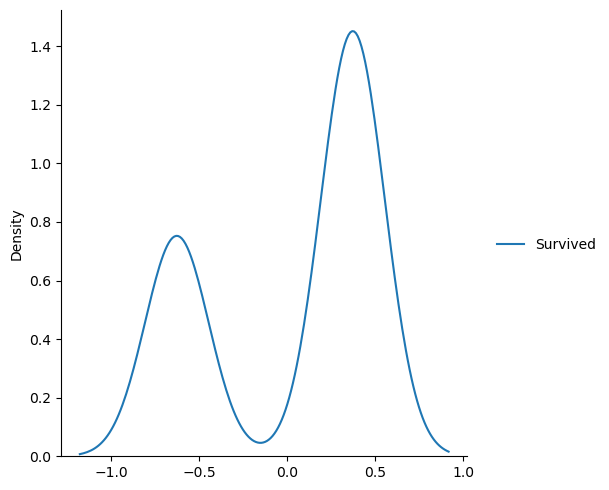

In [ ]:
import seaborn as sns
sns.displot(output-y_test,kind='kde')

This model is very bad because of r2 is very-very under 0 that mean model is bias. Model can not learn 

# Basic Rule of choosing Model for small dataset(data<10000)
If output(y) value is number -- Linear Regression, Ridge, Lasso, Random Forest Regressor, XGBoost Regressor.

If output(y) value is 0&1 -- Logistic Regression, Support Vector Machines, Random Forest Classifier, XGBoost Classifier.
